In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)

In [6]:
import pandas as pd

In [7]:
df = pd.read_excel(r"C:\Users\admin\Downloads\Retail_Banking_Project\Merged_retail_banking.xlsx")

In [8]:
df.head()

,customer_id,age,region,preferred_channel,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,credit_card_issued,loan_taken,Age_group,Balance_Category,month,monthly_transactions,Month_Name,Active customer
0,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-01-01,15,January,yes
1,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-02-01,12,February,No
2,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-03-01,20,March,yes
3,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-04-01,21,April,yes
4,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-05-01,19,May,yes


In [9]:
print(df.columns.tolist())

['customer_id', 'age', 'region', 'preferred_channel', 'monthly_transactions_avg', 'avg_monthly_balance', 'num_products_held', 'digital_adoption_score', 'credit_card_issued', 'loan_taken', 'Age_group', 'Balance_Category', 'month', 'monthly_transactions', 'Month_Name', 'Active customer']


In [10]:
print(df["Active customer"].value_counts())

print("\nUnique values:")
print(df["Active customer"].unique())

Active customer
yes    18588
No      5412
Name: count, dtype: int64

Unique values:
['yes' 'No']


In [11]:
df["Active customer"] = df["Active customer"].replace({
    "yes": 1,
    "No": 0
})

C:\Users\admin\AppData\Local\Temp\ipykernel_16496\2450757675.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Active customer"] = df["Active customer"].replace({


In [12]:
print(df["Active customer"].value_counts())
print(df["Active customer"].dtype)

Active customer
1    18588
0     5412
Name: count, dtype: int64
int64


In [13]:
X = df.drop(columns=["customer_id", "Active customer"])

y = df["Active customer"]

In [14]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns)

Features Shape: (24000, 14)
Target Shape: (24000,)

Features:
Index(['age', 'region', 'preferred_channel', 'monthly_transactions_avg',
       'avg_monthly_balance', 'num_products_held', 'digital_adoption_score',
       'credit_card_issued', 'loan_taken', 'Age_group', 'Balance_Category',
       'month', 'monthly_transactions', 'Month_Name'],
      dtype='object')


In [15]:
print(X.columns)

Index(['age', 'region', 'preferred_channel', 'monthly_transactions_avg',
       'avg_monthly_balance', 'num_products_held', 'digital_adoption_score',
       'credit_card_issued', 'loan_taken', 'Age_group', 'Balance_Category',
       'month', 'monthly_transactions', 'Month_Name'],
      dtype='object')


In [16]:
print(X.dtypes)

age                                  int64
region                              object
preferred_channel                   object
monthly_transactions_avg             int64
avg_monthly_balance                  int64
num_products_held                    int64
digital_adoption_score             float64
credit_card_issued                   int64
loan_taken                           int64
Age_group                           object
Balance_Category                    object
month                       datetime64[ns]
monthly_transactions                 int64
Month_Name                          object
dtype: object


In [17]:
#Remove the Date Column
X = X.drop(columns=["month"])

In [18]:
#Convert Text Columns into Numbers (One-Hot Encoding)
X = pd.get_dummies(
    X,
    columns=[
        "region",
        "preferred_channel",
        "Age_group",
        "Balance_Category",
        "Month_Name"
    ],
    drop_first=True
)

In [20]:
print(X.head())


   age  monthly_transactions_avg  avg_monthly_balance  num_products_held  \
0   56                        23                37632                  2   
1   56                        23                37632                  2   
2   56                        23                37632                  2   
3   56                        23                37632                  2   
4   56                        23                37632                  2   

   digital_adoption_score  credit_card_issued  loan_taken  \
0                    0.52                   0           0   
1                    0.52                   0           0   
2                    0.52                   0           0   
3                    0.52                   0           0   
4                    0.52                   0           0   

   monthly_transactions  region_East  region_North  ...  Month_Name_December  \
0                    15        False         False  ...                False   
1               

In [21]:
print(X.shape)

(24000, 31)


In [22]:
#Split the Data into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (19200, 31)
X_test  : (4800, 31)
y_train : (19200,)
y_test  : (4800,)


In [24]:
#Scale the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
#Train the Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [26]:
#Make Predictions
# Predict customer class (0 or 1)
y_pred = model.predict(X_test)

# Predict probability of being Active
y_prob = model.predict_proba(X_test)[:,1]

In [27]:
#Create the Confusion Matrix
from sklearn.metrics import confusion_matrix

In [28]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1062    0]
 [   0 3738]]


In [29]:
TN, FP, FN, TP = cm.ravel()

print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)

True Negative : 1062
False Positive: 0
False Negative: 0
True Positive : 3738


In [30]:
#Calculate Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 1.0


In [31]:
#Calculate Precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision =", precision)

Precision = 1.0


In [32]:
#Calculate Recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall =", recall)

Recall = 1.0


In [33]:
#Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC =", roc_auc)

ROC-AUC = 1.0


In [34]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1062
           1       1.00      1.00      1.00      3738

    accuracy                           1.00      4800
   macro avg       1.00      1.00      1.00      4800
weighted avg       1.00      1.00      1.00      4800



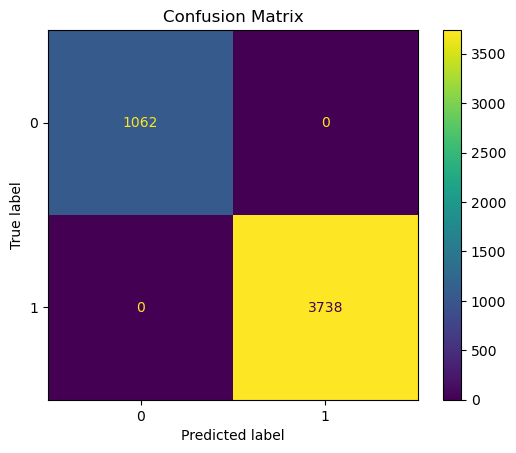

In [36]:
#Plot the Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

Diagnosing Bias and Variance

In [37]:
#Find Training Accuracy
from sklearn.metrics import accuracy_score

# Prediction on training data
y_train_pred = model.predict(X_train)

# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [38]:
#Find Testing Accuracy
# Prediction on test data
y_test_pred = model.predict(X_test)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 1.0


Clustering Validation

In [40]:
print(df.head())

  customer_id  age region preferred_channel  monthly_transactions_avg  \
0  CUST100007   56  South               ATM                        23   
1  CUST100007   56  South               ATM                        23   
2  CUST100007   56  South               ATM                        23   
3  CUST100007   56  South               ATM                        23   
4  CUST100007   56  South               ATM                        23   

   avg_monthly_balance  num_products_held  digital_adoption_score  \
0                37632                  2                    0.52   
1                37632                  2                    0.52   
2                37632                  2                    0.52   
3                37632                  2                    0.52   
4                37632                  2                    0.52   

   credit_card_issued  loan_taken Age_group Balance_Category      month  \
0                   0           0     46-60           Medium 2022-01-01

In [41]:
%who

ConfusionMatrixDisplay	 FN	 FP	 LogisticRegression	 RocCurveDisplay	 StandardScaler	 TN	 TP	 X	 
X_test	 X_train	 accuracy	 accuracy_score	 classification_report	 cm	 confusion_matrix	 dataframe_columns	 dataframe_hash	 
df	 dtypes_str	 get_dataframes	 getpass	 hashlib	 import_pandas_safely	 is_data_frame	 json	 model	 
pd	 plt	 precision	 precision_score	 recall	 recall_score	 roc_auc	 roc_auc_score	 scaler	 
sns	 test_accuracy	 train_accuracy	 train_test_split	 y	 y_pred	 y_prob	 y_test	 y_test_pred	 
y_train	 y_train_pred	 


In [42]:
cluster_features = df[[
    "monthly_transactions_avg",
    "avg_monthly_balance",
    "num_products_held",
    "digital_adoption_score"
]]

cluster_features.head()

,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score
0,23,37632,2,0.52
1,23,37632,2,0.52
2,23,37632,2,0.52
3,23,37632,2,0.52
4,23,37632,2,0.52


In [43]:
#scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_features)

In [44]:
print(cluster_scaled.shape)

(24000, 4)


In [45]:
#Train the K-Means Model
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(cluster_scaled)

In [46]:
print(df["Cluster"].value_counts())

Cluster
3    6504
0    6072
1    5928
2    5496
Name: count, dtype: int64


In [48]:
#Assess Clustering Tendency (Hopkins Statistic)


In [8]:
#Create the Hopkins Function
import numpy as np
from sklearn.neighbors import NearestNeighbors

def hopkins(X):
    X = np.array(X)

    n = X.shape[0]
    d = X.shape[1]

    m = int(0.1 * n)

    rng = np.random.default_rng(42)

    random_indices = rng.choice(n, m, replace=False)
    sample = X[random_indices]

    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)

    random_points = rng.uniform(mins, maxs, (m, d))

    nbrs = NearestNeighbors(n_neighbors=2)
    nbrs.fit(X)

    u_dist, _ = nbrs.kneighbors(random_points, n_neighbors=1)

    w_dist, _ = nbrs.kneighbors(sample, n_neighbors=2)
    w_dist = w_dist[:, 1]

    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())

    return H

In [14]:
import pandas as pd

In [15]:
df = pd.read_excel(r"C:\Users\admin\Downloads\Retail_Banking_Project\Merged_retail_banking.xlsx")

In [16]:
df.head()

,customer_id,age,region,preferred_channel,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,credit_card_issued,loan_taken,Age_group,Balance_Category,month,monthly_transactions,Month_Name,Active customer
0,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-01-01,15,January,yes
1,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-02-01,12,February,No
2,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-03-01,20,March,yes
3,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-04-01,21,April,yes
4,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-05-01,19,May,yes


In [17]:
cluster_features = df[[
    "monthly_transactions_avg",
    "avg_monthly_balance",
    "num_products_held",
    "digital_adoption_score"
]]

In [18]:
#Scale the features again
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_features)

In [19]:
print(cluster_scaled.shape)

(24000, 4)


In [20]:
#Calculate the Hopkins Statistic
hopkins_score = hopkins(cluster_scaled)

print("Hopkins Statistic:", round(hopkins_score, 3))

Hopkins Statistic: 1.0


In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(cluster_scaled)

In [23]:
print(df["Cluster"].value_counts())

Cluster
3    6504
0    6072
1    5928
2    5496
Name: count, dtype: int64


In [25]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(cluster_scaled, df["Cluster"])

print("Silhouette Score:", round(sil_score, 3))

Silhouette Score: 0.197
